**Import Libraries**

In [3098]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.naive_bayes import GaussianNB

**Loading Dataset**

In [3099]:
df_train = pd.read_csv('aug_train.csv')
df_test = pd.read_csv('aug_test.csv')
df_train['source'] = 'train'
df_test['source'] = 'test'
df = pd.concat([df_train, df_test], ignore_index=True)

**Data Exploration**

In [3100]:
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,source
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,train
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,train
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,train
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,train
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21282,1289,city_103,0.920,Male,No relevent experience,no_enrollment,Graduate,Humanities,16,NaN,Public Sector,4,15,NaN,test
21283,195,city_136,0.897,Male,Has relevent experience,no_enrollment,Masters,STEM,18,NaN,NaN,2,30,NaN,test
21284,31762,city_100,0.887,Male,No relevent experience,no_enrollment,Primary School,NaN,3,NaN,Pvt Ltd,never,18,NaN,test
21285,7873,city_102,0.804,Male,Has relevent experience,Full time course,High School,NaN,7,100-500,Public Sector,1,84,NaN,test


In [3101]:
df = df.drop(['enrollee_id', 'city', 'gender'], axis = 1)
df

,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,source
0,0.920,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,train
1,0.776,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,train
2,0.624,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,train
3,0.789,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,train
4,0.767,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,train
...,...,...,...,...,...,...,...,...,...,...,...,...
21282,0.920,No relevent experience,no_enrollment,Graduate,Humanities,16,NaN,Public Sector,4,15,NaN,test
21283,0.897,Has relevent experience,no_enrollment,Masters,STEM,18,NaN,NaN,2,30,NaN,test
21284,0.887,No relevent experience,no_enrollment,Primary School,NaN,3,NaN,Pvt Ltd,never,18,NaN,test
21285,0.804,Has relevent experience,Full time course,High School,NaN,7,100-500,Public Sector,1,84,NaN,test


In [3102]:
df.shape

(21287, 12)

In [3103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21287 entries, 0 to 21286
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  21287 non-null  float64
 1   relevent_experience     21287 non-null  object 
 2   enrolled_university     20870 non-null  object 
 3   education_level         20775 non-null  object 
 4   major_discipline        18162 non-null  object 
 5   experience              21217 non-null  object 
 6   company_size            14727 non-null  object 
 7   company_type            14513 non-null  object 
 8   last_new_job            20824 non-null  object 
 9   training_hours          21287 non-null  int64  
 10  target                  19158 non-null  float64
 11  source                  21287 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 1.9+ MB


*there are null values*

In [3104]:
df.isna().sum()

,0
city_development_index,0
relevent_experience,0
enrolled_university,417
education_level,512
major_discipline,3125
experience,70
company_size,6560
company_type,6774
last_new_job,463
training_hours,0


In [3105]:
df['company_type'] = df['company_type'].fillna('No Company')
df['enrolled_university'] = df['enrolled_university'].fillna('no_enrollment')
df['education_level'] = df['education_level'].fillna(df['education_level'].mode()[0])
df['major_discipline'] = df['major_discipline'].fillna('Unknown')
df['experience'] = df['experience'].fillna(df['experience'].mode()[0])
df['company_size'] = df['company_size'].fillna('Unknown')
df['last_new_job'] = df['last_new_job'].fillna(df['last_new_job'].mode()[0])

In [3106]:
df.head()

,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,source
0,0.920,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,No Company,1,36,1.0,train
1,0.776,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,train
2,0.624,No relevent experience,Full time course,Graduate,STEM,5,Unknown,No Company,never,83,0.0,train
3,0.789,No relevent experience,no_enrollment,Graduate,Business Degree,<1,Unknown,Pvt Ltd,never,52,1.0,train
4,0.767,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,train


In [3107]:
df.tail()

,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,source
21282,0.920,No relevent experience,no_enrollment,Graduate,Humanities,16,Unknown,Public Sector,4,15,NaN,test
21283,0.897,Has relevent experience,no_enrollment,Masters,STEM,18,Unknown,No Company,2,30,NaN,test
21284,0.887,No relevent experience,no_enrollment,Primary School,Unknown,3,Unknown,Pvt Ltd,never,18,NaN,test
21285,0.804,Has relevent experience,Full time course,High School,Unknown,7,100-500,Public Sector,1,84,NaN,test
21286,0.804,Has relevent experience,no_enrollment,Masters,STEM,15,10000+,Pvt Ltd,2,11,NaN,test


In [3108]:
df.describe()

,city_development_index,training_hours,target
count,21287.000000,21287.000000,19158.000000
mean,0.828462,65.328510,0.249348
std,0.123537,60.075201,0.432647
min,0.448000,1.000000,0.000000
25%,0.739000,23.000000,0.000000
50%,0.903000,47.000000,0.000000
75%,0.920000,88.000000,0.000000
max,0.949000,336.000000,1.000000


In [3109]:
df.describe(include='object').T

,count,unique,top,freq
relevent_experience,21287,2,Has relevent experience,15316
enrolled_university,21287,3,no_enrollment,15753
education_level,21287,5,Graduate,13379
major_discipline,21287,7,STEM,16113
experience,21287,22,>20,3739
company_size,21287,9,Unknown,6560
company_type,21287,7,Pvt Ltd,10958
last_new_job,21287,6,1,9387
source,21287,2,train,19158


In [3110]:
df.isna().sum()

,0
city_development_index,0
relevent_experience,0
enrolled_university,0
education_level,0
major_discipline,0
experience,0
company_size,0
company_type,0
last_new_job,0
training_hours,0


In [3111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21287 entries, 0 to 21286
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  21287 non-null  float64
 1   relevent_experience     21287 non-null  object 
 2   enrolled_university     21287 non-null  object 
 3   education_level         21287 non-null  object 
 4   major_discipline        21287 non-null  object 
 5   experience              21287 non-null  object 
 6   company_size            21287 non-null  object 
 7   company_type            21287 non-null  object 
 8   last_new_job            21287 non-null  object 
 9   training_hours          21287 non-null  int64  
 10  target                  19158 non-null  float64
 11  source                  21287 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 1.9+ MB


**Encoding**

*   Check Education Level Unique Values

In [3112]:
df['education_level'].unique()

array(['Graduate', 'Masters', 'High School', 'Phd', 'Primary School'],
      dtype=object)

In [3113]:
CustomizedELevel = {'Primary School': 1, 'High School': 2, 'Graduate': 3, 'Masters': 4, 'Phd': 5}
df['education_level'] = df['education_level'].map(CustomizedELevel)

**Encoding**

*   Check experience Unique Values

In [3114]:
df['experience'].unique()

array(['>20', '15', '5', '<1', '11', '13', '7', '17', '2', '16', '1', '4',
       '10', '14', '18', '19', '12', '3', '6', '9', '8', '20'],
      dtype=object)

*   it doesn't need encoding, only handling [ <1 & >20 ]

In [3115]:
df['experience'] = df['experience'].replace({ '<1': 0, '>20': 21 }).astype(float)

**Encoding**

*   Check experience Unique Values

In [3116]:
df['last_new_job'].unique()

array(['1', '>4', 'never', '4', '3', '2'], dtype=object)

*   it doesn't need encoding, only handling [ >4 & never ]

In [3117]:
df['last_new_job'] = df['last_new_job'].replace({ '>4': 3, 'never': 0 }).astype(float)

**Encoding**

*   Check Company Size Unique Values

In [3118]:
df['company_size'].unique()

array(['Unknown', '50-99', '<10', '10000+', '5000-9999', '1000-4999',
       '10/49', '100-500', '500-999'], dtype=object)

In [3119]:
size_map = {'<10': 1, '10/49': 2, '50-99': 3, '100-500': 4, '500-999': 5,
            '1000-4999': 6, '5000-9999': 7, '10000+': 8, 'Unknown': 0}
df['company_size'] = df['company_size'].map(size_map)

**Encoding**

*   Check Relevant Experience Unique Values

In [3120]:
df['relevent_experience'].unique()

array(['Has relevent experience', 'No relevent experience'], dtype=object)

In [3121]:
df['relevent_experience'] = df['relevent_experience'].map( {'Has relevent experience': 1, 'No relevent experience': 0})


**Encoding**

*   Encoding Company Type, Enrolled University & Major Disipline

In [3122]:
LE = LabelEncoder()
df['company_type'] = LE.fit_transform(df['company_type'])
df['enrolled_university'] = LE.fit_transform(df['enrolled_university'])
df['major_discipline'] = LE.fit_transform(df['major_discipline'])
df
df

,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,source
0,0.920,1,2,3,5,21.0,0,3,1.0,36,1.0,train
1,0.776,0,2,3,5,15.0,3,6,3.0,47,0.0,train
2,0.624,0,0,3,5,5.0,0,3,0.0,83,0.0,train
3,0.789,0,2,3,1,0.0,0,6,0.0,52,1.0,train
4,0.767,1,2,4,5,21.0,3,1,4.0,8,0.0,train
...,...,...,...,...,...,...,...,...,...,...,...,...
21282,0.920,0,2,3,2,16.0,0,5,4.0,15,NaN,test
21283,0.897,1,2,4,5,18.0,0,3,2.0,30,NaN,test
21284,0.887,0,2,1,6,3.0,0,6,0.0,18,NaN,test
21285,0.804,1,0,2,6,7.0,4,5,1.0,84,NaN,test


**split the target from the another features**

In [3123]:
df_train_clean = df[df['source'] == 'train'].drop('source', axis=1)
df_test_clean  = df[df['source'] == 'test'].drop(['source', 'target'], axis=1)
print(df_train_clean.shape)
print(df_test_clean.shape)

(19158, 11)
(2129, 10)


In [3124]:
x = df_train_clean.drop('target', axis=1)
y = df_train_clean['target']

In [3125]:
x.isna().sum()

,0
city_development_index,0
relevent_experience,0
enrolled_university,0
education_level,0
major_discipline,0
experience,0
company_size,0
company_type,0
last_new_job,0
training_hours,0


In [3126]:
y.isna().sum()

np.int64(0)

*no null values so everything is OK*

**Train/Test Split**

*   before scaling to avoid data leakage

In [3127]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [3128]:
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

x_train shape: (15326, 10)
x_test shape: (3832, 10)
y_train shape: (15326,)
y_test shape: (3832,)


In [3129]:
x.agg(['min', 'max'])

,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
min,0.448,0,0,1,0,0.0,0,0,0.0,1
max,0.949,1,2,5,6,21.0,8,6,4.0,336


**Scaling**


*   due to the ranges between the features so the model will not missunderstand the weights
*   i will scale by standardization to avoid misleading of models that assume data is normal distributed and there is an outlier


In [3130]:
from sklearn.preprocessing import StandardScaler
standard = StandardScaler()
x_train_scaled = standard.fit_transform(x_train)
x_test_scaled = standard.transform(x_test)
pd.DataFrame(x_train_scaled, columns=x_train.columns).describe().T[['mean', 'std']]

,mean,std
city_development_index,-1.917065e-16,1.000033
relevent_experience,7.070192e-17,1.000033
enrolled_university,2.503544e-17,1.000033
education_level,-3.338058e-17,1.000033
major_discipline,-2.383003e-16,1.000033
experience,-1.947201e-17,1.000033
company_size,2.804896e-17,1.000033
company_type,-7.047011e-17,1.000033
last_new_job,-2.225372e-17,1.000033
training_hours,-2.781715e-17,1.000033


**Shortcut Function**


*   test model
*   get metrics for evaluation and store each model metrics in a list to make a comparison later
*   print the confusion matrix

In [3131]:
results = {}
roc_data = {}

def evaluate_model(name, model, x_test, y_test, color='Greens'):
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1}

    print(f'{name} Performance:')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1 Score:  {f1:.4f}')
    print('\nClassification Report:\n', classification_report(y_test, y_pred))

    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap=color)
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return y_pred

**Logistic Regression Model**

In [3132]:
logreg = LogisticRegression(max_iter=1000, random_state = 42, class_weight = 'balanced')
logreg.fit(x_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [3133]:
y_train_pred_logreg = logreg.predict(x_train_scaled)

In [3134]:
print("Training Performance:\n\n")
print("Accuracy :", accuracy_score(y_train, y_train_pred_logreg))
print("Precision:", precision_score(y_train, y_train_pred_logreg))
print("Recall   :", recall_score(y_train, y_train_pred_logreg))
print("F1 Score :", f1_score(y_train, y_train_pred_logreg))

Training Performance:


Accuracy : 0.7110139631997912
Precision: 0.44653866478774
Recall   : 0.6632653061224489
F1 Score : 0.5337403937256553


Logistic Regression Performance:
Accuracy:  0.7145
Precision: 0.4531
Recall:    0.7037
F1 Score:  0.5513

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.72      0.79      2877
         1.0       0.45      0.70      0.55       955

    accuracy                           0.71      3832
   macro avg       0.67      0.71      0.67      3832
weighted avg       0.77      0.71      0.73      3832



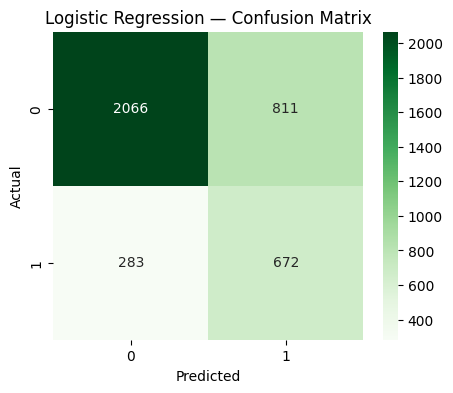

In [3135]:
y_pred_logreg = evaluate_model('Logistic Regression', logreg, x_test_scaled, y_test)

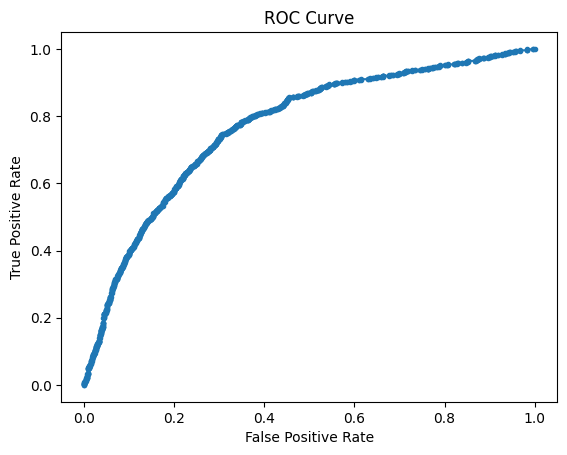

AUC Score: 0.7684347970089553


In [3136]:
y_prob = logreg.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score}")

**Decision Tree Model**

In [3137]:
dt = DecisionTreeClassifier(criterion = "gini", max_depth = 7, random_state = 42, class_weight = 'balanced')
dt.fit(x_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=7, random_state=42)

In [3138]:
y_train_pred_dt = dt.predict(x_train_scaled)

In [3139]:
print("Training Performance:\n\n")
print("Accuracy :", accuracy_score(y_train, y_train_pred_dt))
print("Precision:", precision_score(y_train, y_train_pred_dt))
print("Recall   :", recall_score(y_train, y_train_pred_dt))
print("F1 Score :", f1_score(y_train, y_train_pred_dt))

Training Performance:


Accuracy : 0.7868980816912436
Precision: 0.5539177657098526
Recall   : 0.7472527472527473
F1 Score : 0.6362218756961462


Decision Tree (Test) Performance:
Accuracy:  0.7737
Precision: 0.5323
Recall:    0.7602
F1 Score:  0.6261

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.78      0.84      2877
         1.0       0.53      0.76      0.63       955

    accuracy                           0.77      3832
   macro avg       0.72      0.77      0.73      3832
weighted avg       0.81      0.77      0.79      3832



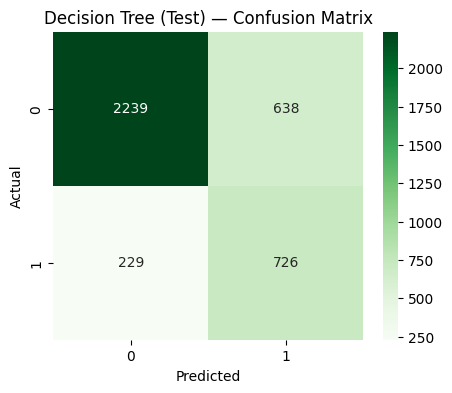

In [3140]:
y_pred_dt = evaluate_model('Decision Tree (Test)', dt, x_test_scaled, y_test)

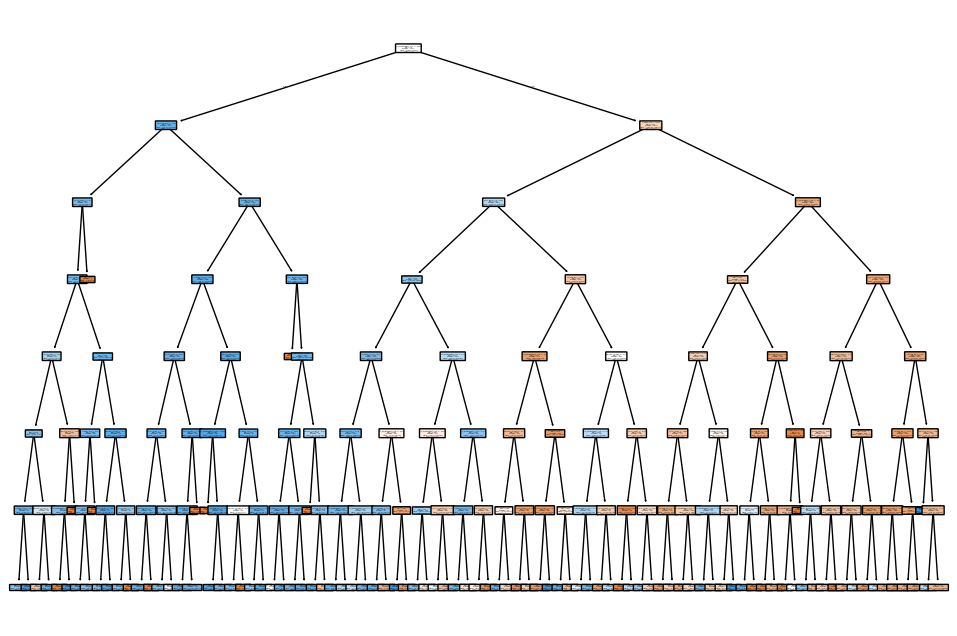

In [3141]:
plt.figure(figsize=(12,8))
plot_tree(dt, filled=True, feature_names=x.columns, class_names=['Not Hired', 'Hired'], rounded=True)
plt.show()

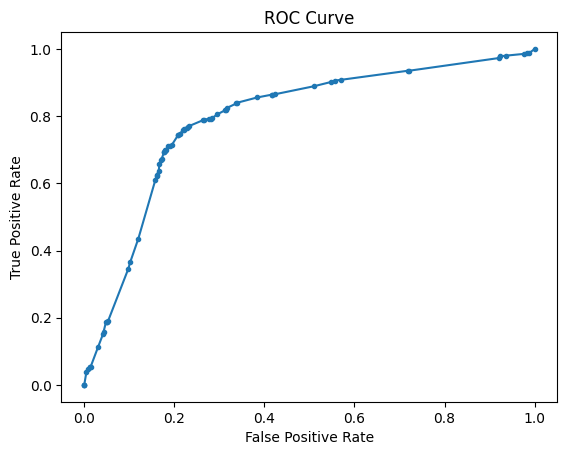

AUC Score: 0.7934044516266399


In [3142]:
y_prob = dt.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score}")

**Naive Bayes**

In [3143]:
gnb = GaussianNB()
gnb.fit(x_train_scaled, y_train)

GaussianNB()

In [3144]:
y_train_pred_gnb = gnb.predict(x_train_scaled)

In [3145]:
print("Training Performance:\n\n")
print("Accuracy :", accuracy_score(y_train, y_train_pred_gnb))
print("Precision:", precision_score(y_train, y_train_pred_gnb))
print("Recall   :", recall_score(y_train, y_train_pred_gnb))
print("F1 Score :", f1_score(y_train, y_train_pred_gnb))

Training Performance:


Accuracy : 0.7497716299099569
Precision: 0.49830508474576274
Recall   : 0.5
F1 Score : 0.499151103565365


Naive Bayes (Test) Performance:
Accuracy:  0.7516
Precision: 0.5015
Recall:    0.5236
F1 Score:  0.5123

Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.83      0.83      2877
         1.0       0.50      0.52      0.51       955

    accuracy                           0.75      3832
   macro avg       0.67      0.68      0.67      3832
weighted avg       0.76      0.75      0.75      3832



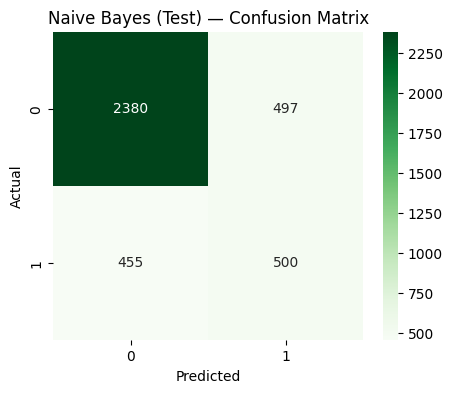

In [3146]:
y_pred_nb = evaluate_model('Naive Bayes (Test)', gnb, x_test_scaled, y_test)

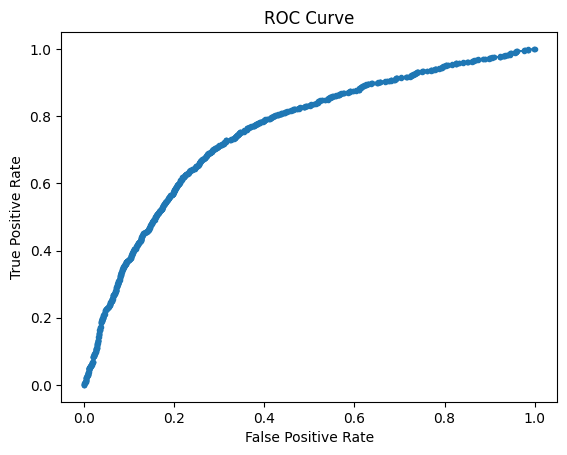

AUC Score: 0.7531847637973674


In [3147]:
y_prob = gnb.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score}")

**Models Evaluation & Comparison**

In [3148]:
results_df = pd.DataFrame(results).T.sort_values('F1 Score', ascending=False)
results_df

,Accuracy,Precision,Recall,F1 Score
Decision Tree (Test),0.773747,0.532258,0.760209,0.626132
Logistic Regression,0.714509,0.453136,0.703665,0.551272
Naive Bayes (Test),0.751566,0.501505,0.523560,0.512295


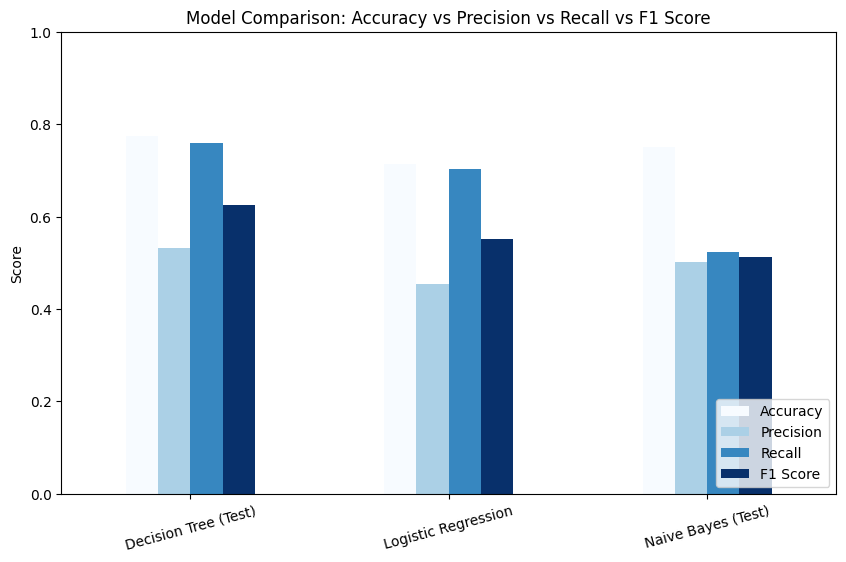

In [3154]:
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot( kind='bar', figsize=(10, 6), colormap='Blues')
plt.title('Model Comparison: Accuracy vs Precision vs Recall vs F1 Score')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.show()

/tmp/ipykernel_1995/73487362.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='Oranges')


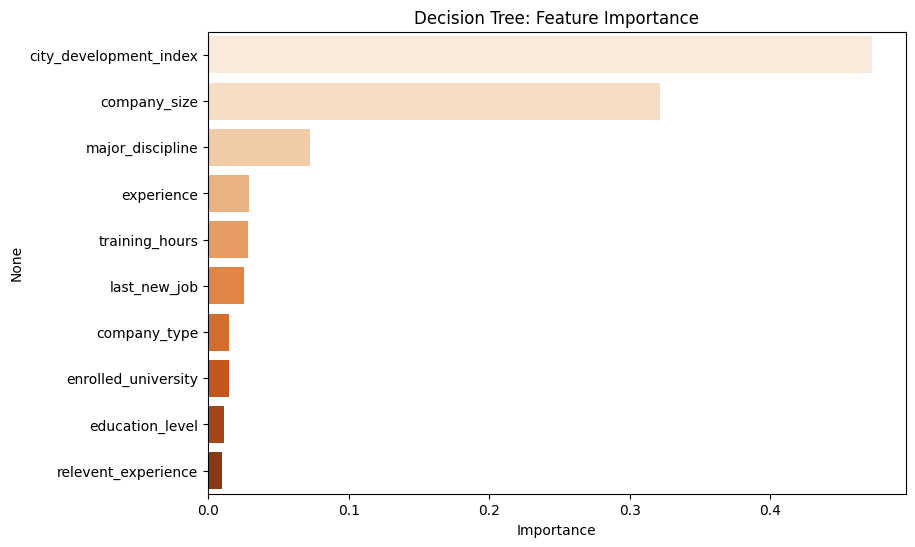

,0
city_development_index,0.472648
company_size,0.321652
major_discipline,0.072114
experience,0.028741
training_hours,0.028408
last_new_job,0.025746
company_type,0.015083
enrolled_university,0.014768
education_level,0.011012
relevent_experience,0.009829


In [3155]:
importances = pd.Series(dt.feature_importances_, index=x_train.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette='Oranges')
plt.title('Decision Tree: Feature Importance')
plt.xlabel('Importance')
plt.show()

importances

**Insights**

In [3161]:
df_raw = pd.read_csv('aug_train.csv')

for col in ['education_level', 'company_type', 'relevent_experience', 'enrolled_university']:
    print(f'--- Target rate by {col} ---\n')
    print(df_raw.groupby(col)['target'].mean().sort_values(ascending=False))
    print('\n\n')

--- Target rate by education_level ---

education_level
Graduate          0.279790
Masters           0.214400
High School       0.195340
Phd               0.140097
Primary School    0.133117
Name: target, dtype: float64



--- Target rate by company_type ---

company_type
Other                  0.239669
Early Stage Startup    0.235489
Public Sector          0.219895
NGO                    0.186180
Pvt Ltd                0.180809
Funded Startup         0.139860
Name: target, dtype: float64



--- Target rate by relevent_experience ---

relevent_experience
No relevent experience     0.338427
Has relevent experience    0.214690
Name: target, dtype: float64



--- Target rate by enrolled_university ---

enrolled_university
Full time course    0.380889
Part time course    0.252087
no_enrollment       0.211406
Name: target, dtype: float64





/tmp/ipykernel_1995/16655748.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, ax=ax, palette='crest')
/tmp/ipykernel_1995/16655748.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, ax=ax, palette='crest')


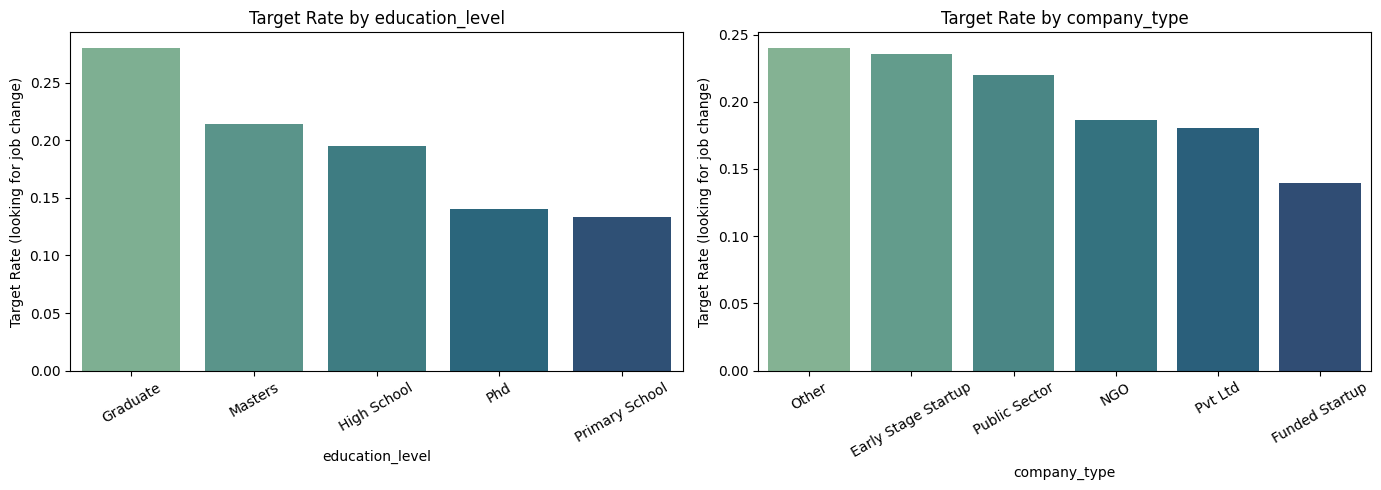

In [3162]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['education_level', 'company_type']):
    rate = df_raw.groupby(col)['target'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette='crest')
    ax.set_title(f'Target Rate by {col}')
    ax.set_ylabel('Target Rate (looking for job change)')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [3163]:
print(f"Total candidates: {len(df_raw):,}")
print(f"Candidates looking for a job change: {df_raw['target'].sum():,.0f}")
print(f"Overall rate: {df_raw['target'].mean():.2%}")

Total candidates: 19,158
Candidates looking for a job change: 4,777
Overall rate: 24.93%
